# Отток клиентов банка. Задача бинарной классификации


---



# ***Table Of Content***

#### Исходные данные:

датасет взят с kaggle:
https://www.kaggle.com/code/aspillai/bank-churn-dataset-classification-lightgbm/input
Датасет содержит инф о клиентах банка.

#### Постановка задачи

> <span style="color:cornflowerblue">🛈 Обучить модель для
> предсказания останется ли пользователь клиентом банка или нет.
> ♦ Сравнить результаты обучения разных моделей.
> ♦ Рассчитать метрики качества модели.
> ♦ Предоставить итоговые выводы. </span>

---


- формат для загрузки =csv
- Столбцы в датасете:
[id, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
- Целевой столбец = **exited**
- Количество строк > 165 000


Примеры значений:
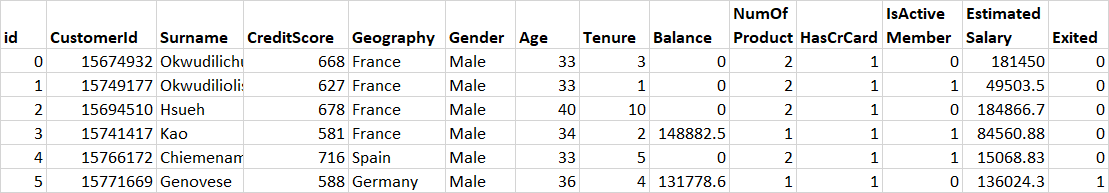

---
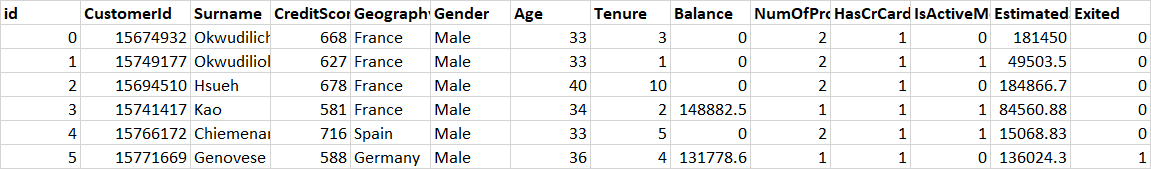

## Расшифровка столбцов

- id: порядковый номер записи(строки) в датасете. Никак не влияет на логику. Исключаю из обработки
- CustomerId: айди пользователя в системе банка. Тоже не должно никак влиять на итог. Исключаю из обработки
- Surname: фамилия пользователя. Пока не понятно надо ли это. Попробую включить в обработку
- CreditScore: кредитный рейтинг. Включаю в обработку
- Geography: видимо гражданство или место проживания пользователя. (К сожалению нет инф где находится сам банк или его филиалы). Включаю в обработку
- Gender: пол пользователя. Включаю в обработку
- Age: возраст, в годах. Включаю в обработку
- Tenure: сколько **лет** пользователь уже клиент банка. Включаю в обработку
- Balance: тут не понятно какой именно баланс (средний, текущий ..) на счетах банка. Включаю в обработку
- NumOfProducts: видимо количество продуктов банка в использовании. Включаю в обработку
- HasCrCard: видимо имеет действующую кредитную карту (посмотреть связи с балансом и с кредитным рейтингом). Включаю в обработку
- IsActiveMember: является активным пользователем (не очень понятен контекст значения). Включаю в обработку
- EstimatedSalary: расчетная зарплата(доход), видимо за год. Включаю в обработку
- Exited: пользователь перестал быть клиентом банка. Целевой столбец для предсказания. Включаю в обработку

---

#### Имена датасетов ниже:


df_raw = pd.read_csv('../bank_churn/bank_churn_raw.csv')


df_filtered
датасет после drop ['id', 'CustomerId', 'Surname']
фичи Geography, Gender -


df_alt_features
датасет после drop ['id', 'CustomerId', 'Surname'] и после удаления всех дубликатов
И Geography, Gender - разложены как ohe


df_expanded = df_alt_features.copy()
добавлены фичи:
Balance_Salary_Ratio, Products_Per_Year, Financial_Activity, Age_Tenure_Interaction


Y = df_alt_features["Exited"] или из df_filtered или из df_expanded - для проверки

X_raw = df_alt_features.drop(["Exited"], axis=1) или из df_filtered или из df_expanded - для обучения

## Раздел 1. Исследование исходных данных

---

In [79]:
from xml.etree.ElementInclude import include

# All imports
# cell enabled

import pandas as pd
import numpy as np
import time
from datetime import datetime, timezone, timedelta

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterSampler # Added for random search

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

model_version = '0.5.6'
# 0.5.6 final polish
# 0.5.5 corrected test split
# 0.5.2 expanded with extra combined features
# 0.5.0 fully refactored


In [80]:
#  Scalers and save csv function
# cell enabled

baseline_scaler = StandardScaler()

# removed scalers dict from loops to save time. Because figured out StandardScaler is better in all runs



# Function to log results into csv file with test flag

def save_results_to_csv(
    model_name,
    scaler_name,
    accuracy,
    recall,
    precision,
    f1,
    train_time,
    filename='ml_logs.csv',
    is_test=False):
    # Added TEST suffix (if is_test True)
    if is_test:
        model_name = f"{model_name}_TEST"

    # time offset (UTC+3)
    TZ_OFFSET = timedelta(hours=3)
    tz = timezone(TZ_OFFSET)
    current_time = datetime.now(tz).isoformat(timespec='seconds')
    print(f'current time is: {current_time}')

    # csv columns result dict
    result = {
        'date_time': current_time,
        'model_name': model_name,
        'scaler': scaler_name,
        'accuracy': round(accuracy, 4),
        'recall': round(recall, 4),
        'precision': round(precision, 4),
        'f1_score': round(f1, 4),
        'train_time_seconds': round(train_time, 4),
        'model_version': model_version
    }

    # result dict to dataframe
    df_result = pd.DataFrame([result])

    # write logs to CSV
    try:
        existing_csv = pd.read_csv(filename)
        df_result.to_csv(filename, mode='a', header=False, index=False)
        print(f'result logged to {filename}')
    except FileNotFoundError:
        df_result.to_csv(filename, mode='w', header=True, index=False)
        print(f'file created: {filename}')


### Раздел 1.1 Загрузка исходных данных

In [81]:
# cell enabled

df_raw = pd.read_csv('bank_churn_raw.csv')


In [82]:
# cell enabled

print(f'total rows, columns: {df_raw.shape}')
df_raw.head()

total rows, columns: (165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


---

### Раздел 1.2 Проверка пропусков и дубликатов

In [83]:
# check gaps in the columns
# cell enabled


df_raw.isnull().sum()

null_amount = df_raw.isnull().sum()

if null_amount.sum() == 0:
    print('data gaps in cells - NO')
else:
    columns_with_null = null_amount[null_amount > 0].to_dict()
    print(columns_with_null)

data gaps in cells - NO


In [84]:
# duplicate check
# cell enabled

duplicate_count = df_raw.duplicated().sum()
print(f'entire row duplicates: {duplicate_count}')

if duplicate_count > 0:
    duplicate_rows = df_raw[df_raw.duplicated()]
    print(duplicate_rows)
    print('-'*15)

# check duplicates in id and CustomerId
for column in ['id']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()
        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicated row index: {dup_indices}')

        dup_values = df_raw[duplicates][column].tolist()
        print(f'duplicated values: {dup_values}\n')
    else:
        print(f'Duplicates in the column: "{column}" - NO\n')



entire row duplicates: 0
Duplicates in the column: "id" - NO



In [85]:
# separated code block because found many duplicates in the column
# cell enabled

for column in ['CustomerId']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()

        if len(dup_indices) >= 200:
            dup_indices_to_show = dup_indices[150:200]
        else:
            dup_indices_to_show = dup_indices

        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicate indexes example:\n {dup_indices_to_show}')

        dup_values = df_raw[duplicates][column].tolist()

        if len(dup_values) >= 200:
            dup_values_to_show = dup_values[150:200]
        else:
            dup_values_to_show = dup_values
        print(f'duplicate values example:\n {dup_values_to_show}\n')
    else:
        print(f'Column "{column}" duplicates - NO\n')

Column "CustomerId" contains: "155733" duplicates
duplicate indexes example:
 [156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207]
duplicate values example:
 [15572767, 15806918, 15757931, 15581261, 15763612, 15576743, 15572038, 15585835, 15604551, 15720353, 15763515, 15592089, 15612494, 15660385, 15682489, 15612043, 15771674, 15594456, 15737408, 15717191, 15812518, 15650424, 15654495, 15662901, 15780142, 15671973, 15596088, 15754072, 15808846, 15709604, 15636731, 15659800, 15606861, 15603088, 15745417, 15587535, 15582841, 15810390, 15771457, 15575391, 15624703, 15626414, 15602851, 15800229, 15806486, 15793049, 15694510, 15595588, 15780056, 15572360]



---
Столбец CustomerId ^ содержит повторы айдишек клиентов, хотя значения в других столбцах отличаются. Чего быть в принципе не должно. Убираю этот столбец из обработки т.к. айди пользователя не влияет на логику решений.

---

In [86]:
# new filtered dataframe
# Столбец с фамилией пока тоже убираю, т.к. не должно влиять
# cell enabled

COLUMNS_DROP = ['id', 'CustomerId', 'Surname']

# df_filtered - dataframe to work with
df_filtered = df_raw.drop(columns=COLUMNS_DROP).copy()
print(f'total rows, columns: {df_filtered.shape}')



# duplicate doublecheck

duplicate_count = df_filtered.duplicated().sum()
print(f'entire row duplicates: {duplicate_count}')

if duplicate_count > 0:
    duplicate_rows = df_filtered[df_filtered.duplicated()]
    print(duplicate_rows)
    print('-' * 15)

    df_filtered = df_filtered.drop_duplicates()
    print(f'Removed {duplicate_count} duplicated rows\n')

print(f'rows:{df_filtered.shape[0]}  columns:{df_filtered.shape[1]}')
duplicate_count = df_filtered.duplicated().sum()
print(f'entire row duplicates: {duplicate_count}')

total rows, columns: (165034, 11)
entire row duplicates: 123
        CreditScore Geography  Gender   Age  Tenure    Balance  NumOfProducts  \
14256           595     Spain    Male  35.0       8       0.00              1   
14736           535    France    Male  33.0       3  133040.32              1   
21512           449     Spain  Female  33.0       8       0.00              2   
27134           532    France    Male  36.0       4       0.00              1   
30350           731    France    Male  43.0       2       0.00              2   
...             ...       ...     ...   ...     ...        ...            ...   
163101          749    France    Male  49.0       1  139290.41              1   
163785          589     Spain    Male  45.0       1       0.00              2   
164350          614     Spain    Male  66.0       2       0.00              2   
164596          682    France    Male  37.0       5       0.00              2   
164996          507     Spain    Male  29.0     

In [87]:
# review column stats
# cell enabled
df_filtered.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,164911.000000,164911,164911,164911.000000,164911.000000,164911.000000,164911.000000,164911.000000,164911.000000,164911.000000,164911.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,94132,93075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,656.468914,NaN,NaN,38.124278,5.020599,55481.138955,1.554420,0.753916,0.497693,112579.798396,0.211684
std,80.091065,NaN,NaN,8.865020,2.806237,62819.233625,0.547171,0.430730,0.499996,50290.229424,0.408503
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74639.870000,0.000000
50%,659.000000,NaN,NaN,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,NaN,NaN,42.000000,7.000000,119948.090000,2.000000,1.000000,1.000000,155155.250000,0.000000


---
---

## Раздел 2. Подготовка данных
Столбцы 'Geography', 'Gender' надо преобразовать в цифровой вид.
Потом нормализовать все столбцы в один масштаб данных

### Раздел 2.1 Текстовые значение в цифровые

In [88]:
# Function to check column details (value, amount in the column, percentage)
# cell enabled

def column_stats_table(df_check, column_check):
    counts = df_check[column_check].value_counts()
    percentages = df_check[column_check].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

    return column_stats


---

In [89]:
# Check column details

column_stats_table(df_filtered,'Geography')

,value,count,percentage
0,France,94132,57.080486
1,Spain,36192,21.946383
2,Germany,34587,20.973131


In [90]:
column_stats_table(df_filtered,'Gender')

,value,count,percentage
0,Male,93075,56.439534
1,Female,71836,43.560466


df_filtered.corr() не работает с категоризованными столбцами через пандас.  надо все-таки явно заменить значения на цифры

LabelEncoder() из sklearn.preprocessing работает норм

In [91]:
# Encode Geography values into numeric type
# cell enabled

if 'Geo_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Geo_encoded'], inplace=True)

geo_encoded = LabelEncoder()
idx = df_filtered.columns.get_loc('Geography')
df_filtered.insert(idx + 1, 'Geo_encoded', geo_encoded.fit_transform(df_filtered['Geography']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,33.0,5,0.00,2,1,1,15068.83,0


In [92]:
# Encode Gender values into numeric
# cell enabled

if 'Gender_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Gender_encoded'], inplace=True)

gender_encoded = LabelEncoder()

idx = df_filtered.columns.get_loc('Gender')
df_filtered.insert(idx + 1, 'Gender_encoded', gender_encoded.fit_transform(df_filtered['Gender']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,1,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,1,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,1,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,1,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,1,33.0,5,0.00,2,1,1,15068.83,0


In [93]:
# Drop original columns with object types
# cell enabled

df_filtered.drop(columns = ['Geography', 'Gender'], inplace=True)

# Correlation check
df_filtered.corr()

,CreditScore,Geo_encoded,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.005334,0.002250,-0.008832,0.000969,0.006880,0.011360,-0.002851,0.014944,-0.001866,-0.027541
Geo_encoded,0.005334,1.000000,-0.012055,0.034109,0.000197,0.134652,-0.025187,-0.016604,-0.003500,-0.004211,0.053225
Gender_encoded,0.002250,-0.012055,1.000000,-0.063287,0.008876,-0.014585,0.025934,0.006311,0.033834,-0.007794,-0.146469
Age,-0.008832,0.034109,-0.063287,1.000000,-0.010797,0.064426,-0.102274,-0.012282,0.003161,-0.005533,0.341009
Tenure,0.000969,0.000197,0.008876,-0.010797,1.000000,-0.009532,0.007387,0.005358,-0.005509,0.001082,-0.019557
Balance,0.006880,0.134652,-0.014585,0.064426,-0.009532,1.000000,-0.360986,-0.018569,-0.014984,0.008566,0.129669
NumOfProducts,0.011360,-0.025187,0.025934,-0.102274,0.007387,-0.360986,1.000000,0.005441,0.039741,-0.004322,-0.214598
HasCrCard,-0.002851,-0.016604,0.006311,-0.012282,0.005358,-0.018569,0.005441,1.000000,-0.021023,0.004581,-0.022141
IsActiveMember,0.014944,-0.003500,0.033834,0.003161,-0.005509,-0.014984,0.039741,-0.021023,1.000000,-0.008084,-0.210254
EstimatedSalary,-0.001866,-0.004211,-0.007794,-0.005533,0.001082,0.008566,-0.004322,0.004581,-0.008084,1.000000,0.018722


---
## Раздел 2. Подготовка к обучению

проверим соотношение значений в целевом столбце

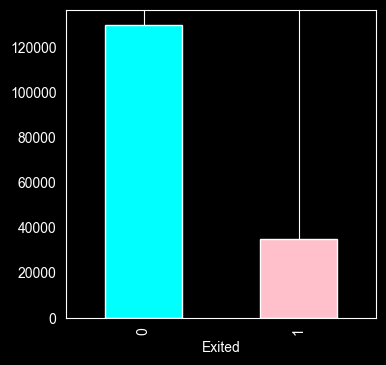

In [94]:
# cell enabled
colors = ['cyan', 'pink', 'blue']
df_filtered['Exited'].value_counts().plot.bar(figsize=(4, 4), color=colors)
plt.grid(axis='y')
target_col = 'Exited'


In [95]:
column_stats_table(df_filtered, 'Exited')

,value,count,percentage
0,0,130002,78.831612
1,1,34909,21.168388



следующий шаг: проверить распределения значений по всем колонкам в датасете

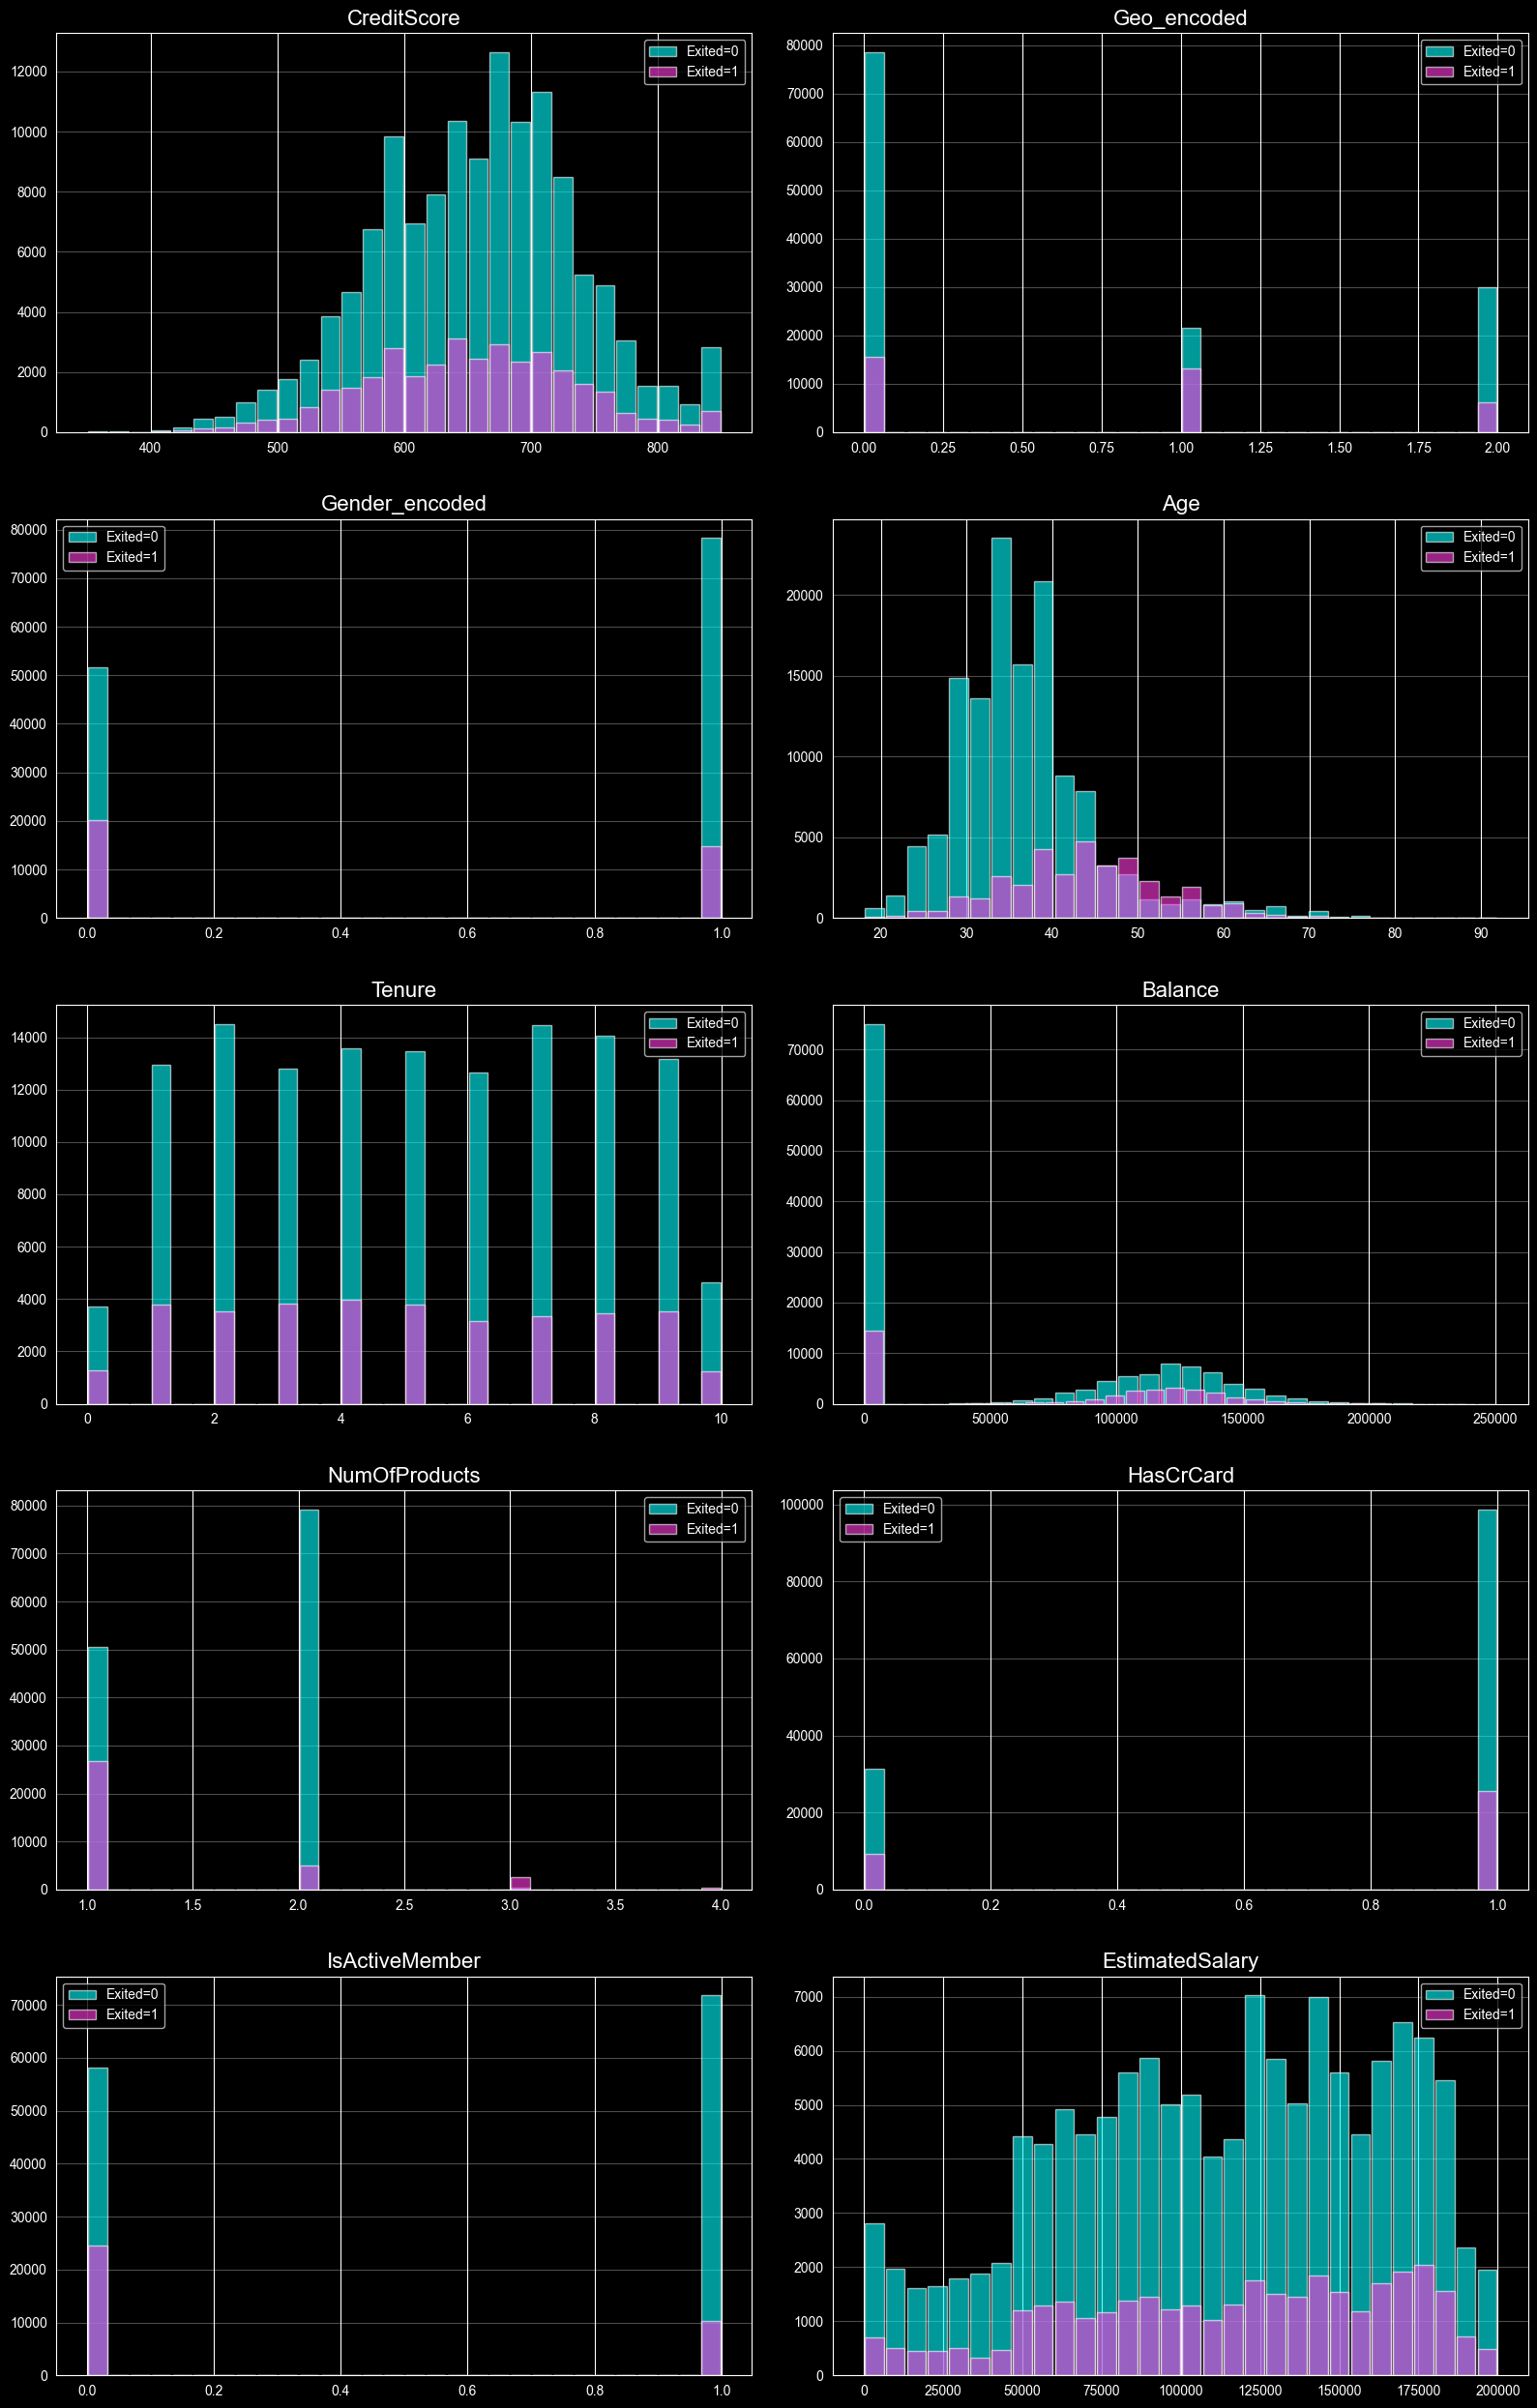

In [96]:


plt.rc('axes', titlesize=16)



num_cols = [c for c in df_filtered.select_dtypes('number').columns if c != target_col]

total_plots = len(num_cols)
required_rows = (total_plots + 1) // 2


fig, axes = plt.subplots(required_rows, 2, figsize=(16, required_rows * 5))
axes = axes.flatten()
colors = ['cyan', '#FF3BDE', '#fa05e5']  # '#FF3BDE' pinky shades

# draw column plots
for idx, col in enumerate(num_cols):
    ax = axes[idx]

    # map colors from target
    for i, val in enumerate(df_filtered[target_col].unique()):
        subset = df_filtered[df_filtered[target_col] == val]

        ax.hist(subset[col], bins=30, alpha=0.6, rwidth=0.9,
                label=f'{target_col}={val}',
                color=colors[i % len(colors)])

    ax.set_title(col)
    ax.legend()  # show legend
    ax.grid(axis='y', alpha=0.3)

# hide unused draw slots
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.show()


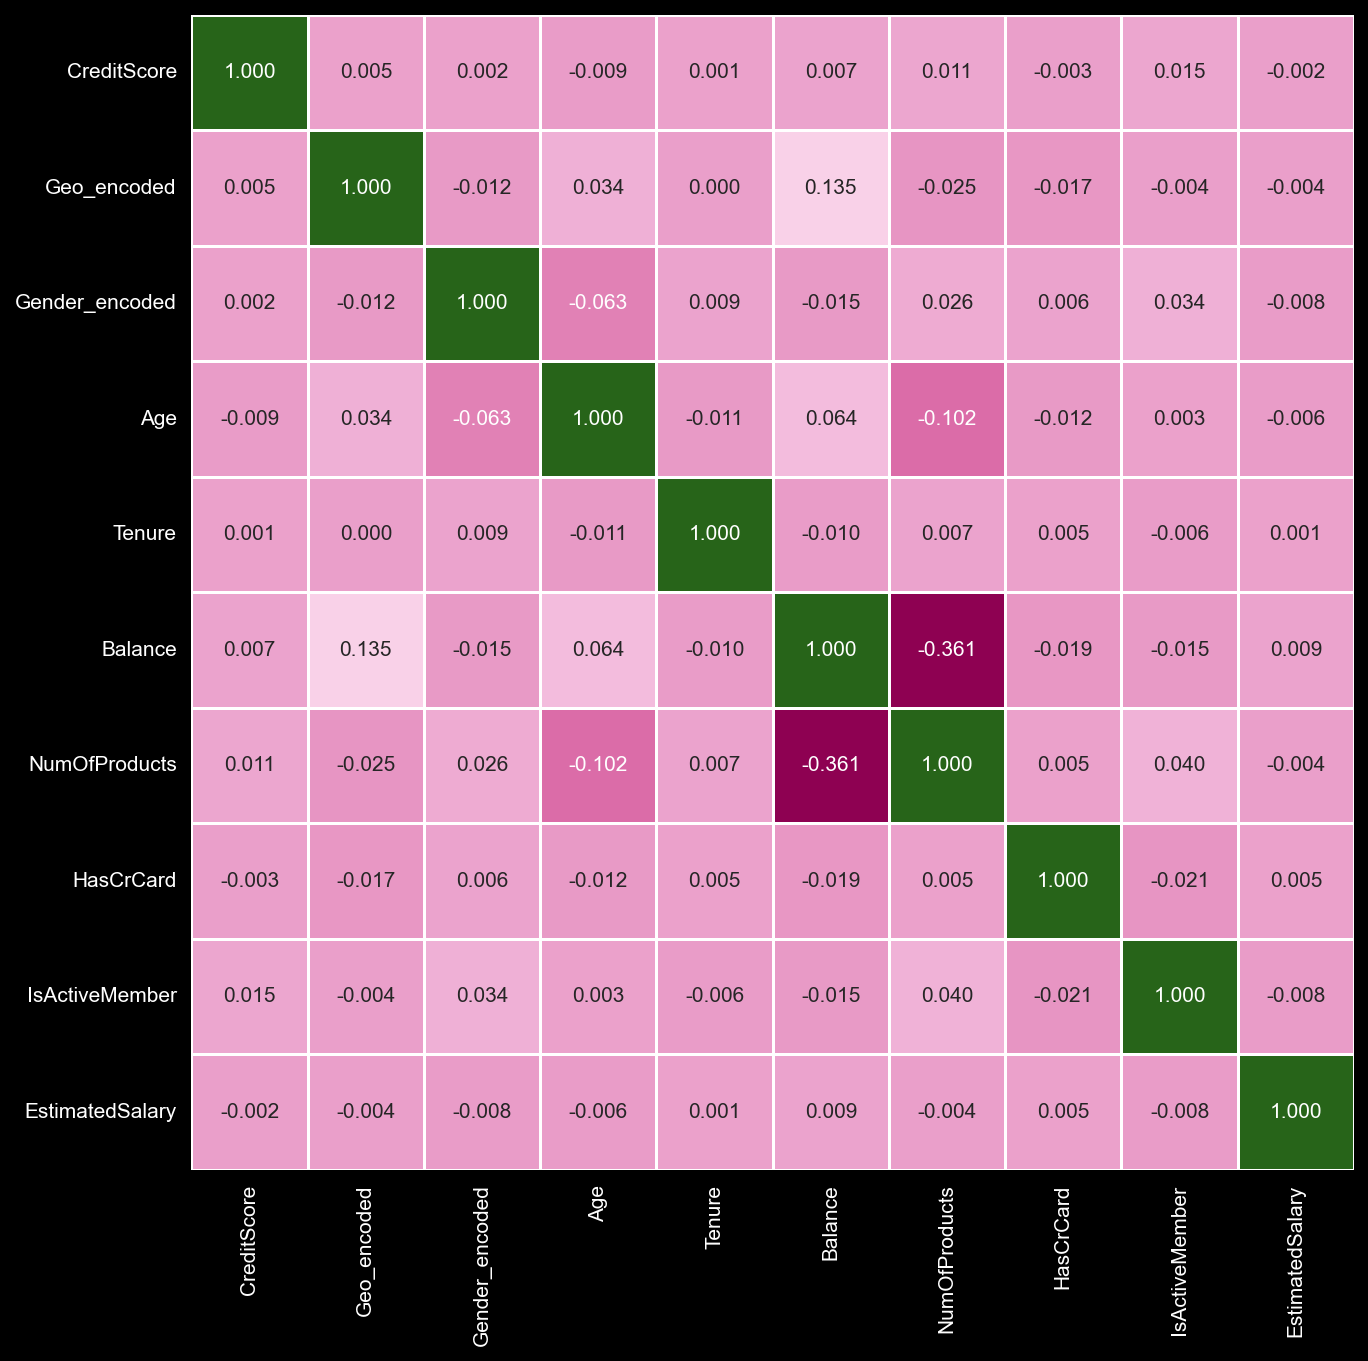

In [97]:
# Correlations without target column, as heatmap render

# plt.figure(figsize=(10, 10))
# sns.heatmap(df_filtered.drop(['Exited'], axis=1).corr(), annot=True, cbar=False, linewidths=.5, fmt= '.3f')
# plt.show()

plt.figure(figsize=(10, 10), dpi=150)

corr_matrix = df_filtered.drop(['Exited'], axis=1, errors='ignore').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cbar=False,
    linewidths=.5,
    fmt='.3f',
    cmap='PiYG',          # 'cool', 'PiYG'
    annot_kws={"size": 10}
)

plt.show()

максимальное значение - |0.361|, нет смысла перенастраивать стобцы, связанность не значительная

In [98]:
# Extra feature engineering (for catboost initially)
# Separate data frame copy to experiment with features.
# Set this block here to try all models with ohe features
# on

COLUMNS_DROP = ['id', 'CustomerId', 'Surname']
df_alt_features = df_raw.drop(columns=COLUMNS_DROP).copy()

print(f'total dataset rows:{df_alt_features.shape[0]}')
duplicate_count = df_alt_features.duplicated().sum()
print(f'entire row duplicates: {duplicate_count}')

if duplicate_count > 0:
    duplicate_rows = df_alt_features[df_alt_features.duplicated()]

    df_alt_features = df_alt_features.drop_duplicates()
    print(f'Removed {duplicate_count} duplicated rows\n')

print(f'rows:{df_alt_features.shape[0]}  columns:{df_alt_features.shape[1]}')
duplicate_count = df_alt_features.duplicated().sum()
print(f'entire row duplicates: {duplicate_count}')

# Geography replacement 1 to 3 cols
#column_stats_table(df_alt_features,'Geography')

geo_cols = []
geo_cols = df_alt_features.columns[df_alt_features.columns.str.startswith('Geo_')]
if geo_cols.size > 0:
    df_alt_features.drop(columns=geo_cols, inplace=True)

# join ohe columns, drop the original column after that
idx = df_alt_features.columns.get_loc('Geography')
geo_ohe = pd.get_dummies(df_alt_features['Geography'], prefix='Geo', dtype=int)

for i, col_name in enumerate(geo_ohe.columns):
    df_alt_features.insert(idx +1 +i, col_name, geo_ohe[col_name])


# Gender replacement 1 to 2 cols
column_stats_table(df_alt_features,'Gender')

geo_cols = []
geo_cols = df_alt_features.columns[df_alt_features.columns.str.startswith('Gender_')]
if geo_cols.size > 0:
    df_alt_features.drop(columns=geo_cols, inplace=True)

# join ohe columns, drop the original column after that
idx = df_alt_features.columns.get_loc('Gender')
geo_ohe = pd.get_dummies(df_alt_features['Gender'], prefix='Gender', dtype=int)

for i, col_name in enumerate(geo_ohe.columns):
    df_alt_features.insert(idx +1 +i, col_name, geo_ohe[col_name])

df_alt_features = df_alt_features.drop(['Geography','Gender'], axis=1)

print('-'*25)
print(f'\nDF shape after Geo and Gender encoding')
print(f'rows:{df_alt_features.shape[0]}  columns:{df_alt_features.shape[1]}')

df_alt_features.head()
# now this df is ready for processing

total dataset rows:165034
entire row duplicates: 123
Removed 123 duplicated rows

rows:164911  columns:11
entire row duplicates: 0
-------------------------

DF shape after Geo and Gender encoding
rows:164911  columns:14


,CreditScore,Geo_France,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,1,0,0,0,1,33.0,3,0.00,2,1,0,181449.97,0
1,627,1,0,0,0,1,33.0,1,0.00,2,1,1,49503.50,0
2,678,1,0,0,0,1,40.0,10,0.00,2,1,0,184866.69,0
3,581,1,0,0,0,1,34.0,2,148882.54,1,1,1,84560.88,0
4,716,0,0,1,0,1,33.0,5,0.00,2,1,1,15068.83,0


In [70]:
# normalization function setup
# this function TO BE DEPRECATED after fixing logic via pipeline instead
# off

# def normalize_columns(dataset_input, scaler_name):
#     # scalers being taken from scaler dict (StandardScaler, MinMaxScaler, RobustScaler)
#
#     # columns to normalize - numeric, not binary
#     cols_to_norm = [col for col in dataset_input.select_dtypes(include=['int64', 'float64']).columns
#                     if not set(dataset_input[col].unique()).issubset({0, 1})]
#
#     # binary columns
#     binary_cols = [col for col in dataset_input.select_dtypes(include=['int64', 'float64']).columns
#                    if set(dataset_input[col].unique()).issubset({0, 1})]
#
#     # normalize numeric columns
#     dataset_norm = dataset_input[cols_to_norm].copy()
#
#     if cols_to_norm:
#         dataset_norm[cols_to_norm] = scaler_name.fit_transform(dataset_norm[cols_to_norm])
#
#     if binary_cols:
#         dataset_norm = pd.concat([dataset_norm, dataset_input[binary_cols]], axis=1)
#
#     print('-'*15)
#     print(f'Scaler used: {scaler_name.__class__.__name__}')
#     print(f'Normalized columns: {cols_to_norm}')
#     print(f'Binary columns as is: {binary_cols}')
#     print('-'*15)
#
#     return dataset_norm





In [129]:
# ============================================
# Expanded df copy with extra feature engineering
# ============================================
# cell enabled

df_expanded = df_alt_features.copy()

# 1. Balance-to-Salary Ratio (Identifies high-earners with empty accounts)
df_expanded['Balance_Salary_Ratio'] = df_expanded['Balance'] / (df_expanded['EstimatedSalary'] + 1)

# 2. Product Utilization Velocity (How fast they adopt products relative to time spent)
df_expanded['Products_Per_Year'] = df_expanded['NumOfProducts'] / (df_expanded['Tenure'] + 1)

# 3. Financial Activity Index (Combines credit card ownership and active membership status)
df_expanded['Financial_Activity'] = df_expanded['HasCrCard'] + df_expanded['IsActiveMember']

# 4. Age and Tenure Interaction (Differentiates young new accounts from older loyal accounts)
df_expanded['Tenure_Age_Interaction'] = df_expanded['Age'] * df_expanded['Tenure']

# 5. Age as categories (based on the Age-to-target effect)
bins = [0, 16, 24, 37, 46, 61, np.inf]
labels = ['0-15', '17-23', '24-36', '37-45', '46-60','61+']

# new category column
# right=False means the lower boundary is included, upper is excluded (e.g., 18 goes into '18-34')
# df_expanded["Age_Category"] = pd.cut(df_expanded["Age"], bins=bins, labels=labels, right=False)
#
#
# # ohe for age cats
# age_cols = []
# age_cols = df_alt_features.columns[df_alt_features.columns.str.startswith('age_')]
# if age_cols.size > 0:
#     df_expanded.drop(columns=age_cols, inplace=True)
#
# # join ohe columns, drop the original column after that
# idx = df_expanded.columns.get_loc('Age_Category')
# age_ohe = pd.get_dummies(df_expanded['Age_Category'], prefix='age_', dtype=int)
#
# for i, col_name in enumerate(age_ohe.columns):
#     df_expanded.insert(idx +1 +i, col_name, age_ohe[col_name])
#
# df_expanded.drop(columns=['Age','Age_Category', 'age__0-15'], inplace=True)

print(f"Features successfully expanded from {df_alt_features.shape[1]} to {df_expanded.shape[1]} columns")
df_expanded.head()


Features successfully expanded from 14 to 18 columns


,CreditScore,Geo_France,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,Products_Per_Year,Financial_Activity,Tenure_Age_Interaction
0,668,1,0,0,0,1,33.0,3,0.00,2,1,0,181449.97,0,0.000000,0.500000,1,99.0
1,627,1,0,0,0,1,33.0,1,0.00,2,1,1,49503.50,0,0.000000,1.000000,2,33.0
2,678,1,0,0,0,1,40.0,10,0.00,2,1,0,184866.69,0,0.000000,0.181818,1,400.0
3,581,1,0,0,0,1,34.0,2,148882.54,1,1,1,84560.88,0,1.760634,0.333333,2,68.0
4,716,0,0,1,0,1,33.0,5,0.00,2,1,1,15068.83,0,0.000000,0.333333,2,165.0


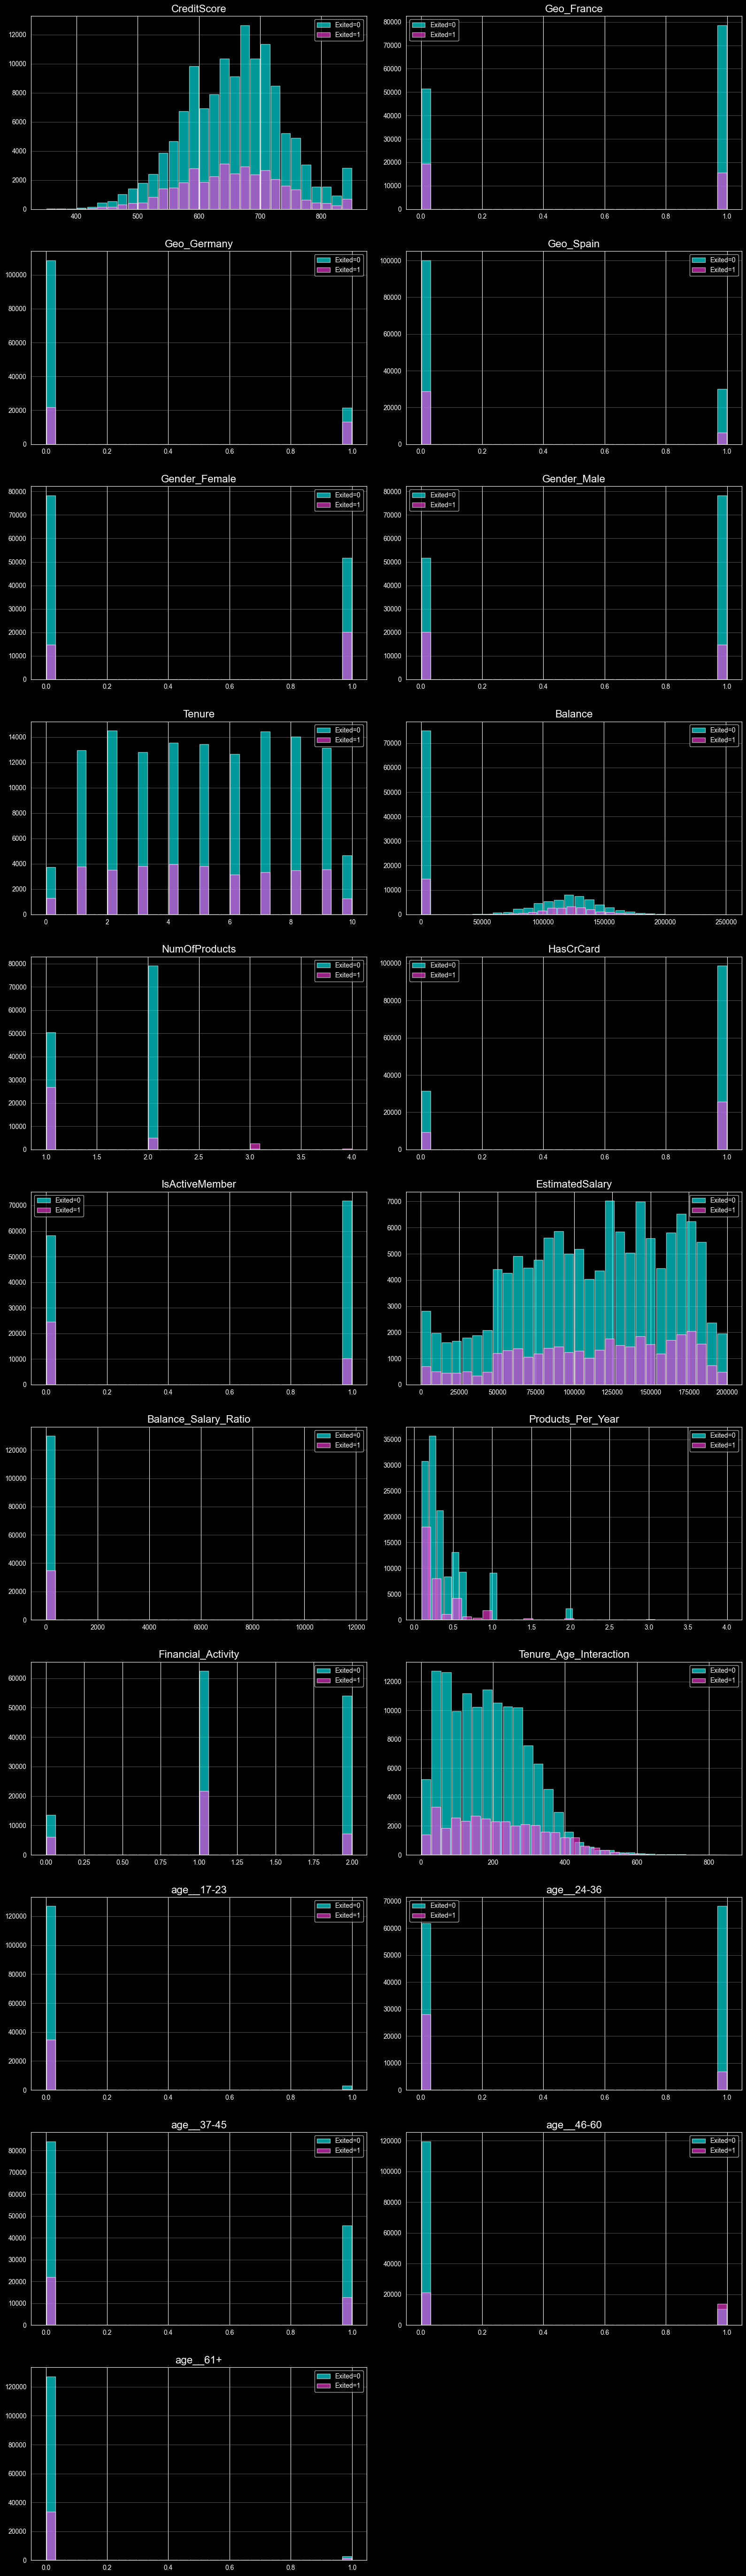

In [126]:

plt.rc('axes', titlesize=16)



num_cols = [c for c in df_expanded.select_dtypes('number').columns if c != target_col]

total_plots = len(num_cols)
required_rows = (total_plots + 1) // 2


fig, axes = plt.subplots(required_rows, 2, figsize=(16, required_rows * 5))
axes = axes.flatten()
colors = ['cyan', '#FF3BDE', '#fa05e5']  # '#FF3BDE' pinky shades

# draw column plots
for idx, col in enumerate(num_cols):
    ax = axes[idx]

    # map colors from target
    for i, val in enumerate(df_expanded[target_col].unique()):
        subset = df_expanded[df_expanded[target_col] == val]

        ax.hist(subset[col], bins=30, alpha=0.6, rwidth=0.9,
                label=f'{target_col}={val}',
                color=colors[i % len(colors)])

    ax.set_title(col)
    ax.legend()  # show legend
    ax.grid(axis='y', alpha=0.3)

# hide unused draw slots
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.show()

In [100]:
# ============================================
# Training logic automation
# ============================================
# cell enabled

# Cross validation setup
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=555)

def train_model_with_scalers(
    model,
    model_name_for_log,
    X_scaled,
    Y_df,
    cv_strategy,
    scaler_name=baseline_scaler,
):

    results_list = []

    print(f'\n{"-"*15}')
    print(f"Training {model_name_for_log} with {scaler_name}")
    print(f'\n{"-"*15}')

    # Pipeline approach
    baseline_scaler = StandardScaler()
    pipeline = Pipeline([("scaler", baseline_scaler), ("classifier", model)])

    # Track train time
    start_time = time.time()

    # Optimized: Performs cross-validation for all metrics in one go (each fold run)
    scoring_metrics = ["accuracy", "recall", "precision", "f1"]
    cv_results = cross_validate(
        pipeline, X_scaled, Y_df, cv=cv_strategy, scoring=scoring_metrics
    )

    train_time = time.time() - start_time

    # mean metric values extracted
    mean_accuracy = cv_results["test_accuracy"].mean()
    mean_recall = cv_results["test_recall"].mean()
    mean_precision = cv_results["test_precision"].mean()
    mean_f1 = cv_results["test_f1"].mean()

    # Display results
    print(f"Train time: {train_time:.4f} seconds")
    print(
        f'Accuracy: {mean_accuracy:.4f} (+/- {cv_results["test_accuracy"].std() * 2:.4f})'
    )
    print(f"Recall: {mean_recall:.4f}")
    print(f"Precision: {mean_precision:.4f}")
    print(f"F1-Score: {mean_f1:.4f}")

    # Save to CSV
    save_results_to_csv(
        model_name=f"{model_name_for_log}",
        scaler_name=scaler_name,
        accuracy=mean_accuracy,
        recall=mean_recall,
        precision=mean_precision,
        f1=mean_f1,
        train_time=train_time,
    )

    results_list.append(
        {
            "scaler": scaler_name,
            "accuracy": mean_accuracy,
            "recall": mean_recall,
            "precision": mean_precision,
            "f1": mean_f1,
            "train_time": train_time,
        }
    )

    return results_list


In [73]:
# ============================================
# BLOCK 20: LOGISTIC REGRESSION
# ============================================

print('\n' + "="*15)
print('MODEL 1: LOGISTIC REGRESSION')
print('-'*15)

Y = df_expanded['Exited']
X_raw = df_expanded.drop(['Exited'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_raw, Y, test_size=0.2, random_state=555, stratify=Y)

# Find best parameters
print("Grid search for Logistic Regression model via Random Search...")
best_logreg_f1 = 0
best_logreg_params = None

# Parameter spaces declared as lists
C_values = [0.0001, 0.0005, 0.0010, 0.002, 0.005, ]
l1_ratio_values = [0.65, 0.66, 0.67, 0.7, 0.9,]
max_iterations = 500

# Combine parameters into a distribution dictionary for random search
param_distributions = {
    "C": C_values,
    "l1_ratio": l1_ratio_values
}

# Define number of random iterations to search
n_iter_search = 30

# Generate the random parameter combinations
random_param_list = list(ParameterSampler(param_distributions, n_iter=n_iter_search, random_state=555))

for params in random_param_list:
    C = params["C"]
    l1_ratio = params["l1_ratio"]

    # Explicitly set penalty to elasticnet if l1_ratio is used with SAGA solver
    # This prevents warnings or errors in several scikit-learn versions
    penalty_type = "elasticnet" if 0 < l1_ratio < 1 else ("l1" if l1_ratio == 1 else "l2")

    logreg_temp = LogisticRegression(
        penalty=penalty_type,
        C=C,
        l1_ratio=l1_ratio if penalty_type == "elasticnet" else None,
        solver="saga",
        max_iter=max_iterations,
        random_state=555,
        class_weight="balanced",  # for imbalanced data (my target is 79/21)
    )

    if l1_ratio == 0:
        reg_type = "L2"
    elif l1_ratio == 1:
        reg_type = "L1"
    else:
        reg_type = f"ElasticNet({l1_ratio})"

    # Applied pipeline function for grid search
    baseline_scaler = StandardScaler()
    search_pipeline = Pipeline(
        [("scaler", baseline_scaler), ("classifier", logreg_temp)]
    )

    # F1 score metric
    f1_scores = cross_val_score(
        search_pipeline, X_raw, Y, cv=cv, scoring="f1"
    )
    mean_f1 = f1_scores.mean()
    print(f"C={C}, {reg_type}: F1={mean_f1:.4f}")

    if mean_f1 > best_logreg_f1:
        best_logreg_f1 = mean_f1
        best_logreg_params = {
            "C": C,
            "l1_ratio": l1_ratio,
            "reg_type": reg_type,
            "penalty": penalty_type
        }

print(
    f'\nBest parameters: C={best_logreg_params["C"]}, {best_logreg_params["reg_type"]}'
)
print(f"Best F1={best_logreg_f1:.4f}")

# check best model
logreg_best = LogisticRegression(
    penalty=best_logreg_params["penalty"],
    C=best_logreg_params["C"],
    l1_ratio=best_logreg_params["l1_ratio"] if best_logreg_params["penalty"] == "elasticnet" else None,
    solver="saga",
    max_iter=max_iterations,
    random_state=555,
    class_weight="balanced",  # added to rebalance and increase recall
)

# Train best found model
logreg_results = train_model_with_scalers(
    model=logreg_best,
    model_name_for_log=f'LogisticRegression_C{best_logreg_params["C"]}_{best_logreg_params["reg_type"]}_balanced',
    X_scaled=X_raw,  # To scale it fold-by-fold
    Y_df=Y,
    cv_strategy=cv,
)

# ====================
# Final check model on test data
# ====================

print(f'\n{"="*40}')
print("FINAL MODEL EVALUATION ON TEST DATA")
print(f'{"="*40}')

# Train final model on ALL training data (without cross-validation)
print('Training final model on training set ..')
start_time = time.time()
logreg_best.fit(X_train, y_train)
train_time = time.time() - start_time
print(f'Training time: {train_time:.4f} seconds')

# Predict on test set
print('Test the model on test set ..')
y_pred = logreg_best.predict(X_test)

# Calculate test metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

test_accuracy = accuracy_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f'\n{"="*30}')
print('TEST SET PERFORMANCE:')
print(f'{"="*30}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Recall:    {test_recall:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test F1-Score:  {test_f1:.4f}')

# Display confusion matrix
print(f'\n{"="*30}')
print('CONFUSION MATRIX:')
print(f'{"="*30}')
print(confusion_matrix(y_test, y_pred))

# Display classification report
print(f'\n{"="*30}')
print('CLASSIFICATION REPORT:')
print(f'{"="*30}')
print(classification_report(y_test, y_pred, target_names=['Not Exited', 'Exited']))

# Save test results to CSV (optional)
try:
    save_results_to_csv(
    model_name=f"LogisticRegression_C{best_logreg_params['C']}_{best_logreg_params['reg_type']}",
    scaler_name="StandardScaler",
    accuracy=test_accuracy,
    recall=test_recall,
    precision=test_precision,
    f1=test_f1,
    train_time=train_time,
    filename='ml_logs.csv',
    is_test=True  # to add _TEST suffix
    )
    print('\nTest results saved to CSV')
except:
    print('\nNote: Could not save test results to CSV (save_results_to_csv function may need test set parameter)')

# Compare CV performance vs Test performance
print(f'\n{"="*30}')
print("PERFORMANCE COMPARISON: CV vs TEST")
print(f'{"="*30}')
# Fixed: Added [0] index to handle the list return structure
print(f"Cross-Validation F1 (average): {logreg_results[0]['f1'] if logreg_results else 'N/A':.4f}")
print(f"Test Set F1:                    {test_f1:.4f}")
print(f"Difference (CV - Test):         {(logreg_results[0]['f1'] - test_f1) if logreg_results else 'N/A':.4f}")

if logreg_results and (logreg_results[0]['f1'] - test_f1) > 0.05:
    print('Warning: Large gap between CV and test performance - possible overfitting')
else:
    print('Test performance is consistent with cross-validation')
print(f'{"="*30}')



MODEL 1: LOGISTIC REGRESSION
---------------
Grid search for Logistic Regression model via Random Search...


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 25 is smaller than n_iter=30. Running 25 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rati

C=0.0001, ElasticNet(0.65): F1=0.5625


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

C=0.0001, ElasticNet(0.66): F1=0.5630


...

C=0.005, ElasticNet(0.9): F1=0.5588

Best parameters: C=0.0001, ElasticNet(0.7)
Best F1=0.5640

---------------
Training LogisticRegression_C0.0001_ElasticNet(0.7)_balanced with StandardScaler()

---------------


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Train time: 5.5423 seconds
Accuracy: 0.7616 (+/- 0.0087)
Recall: 0.7281
Precision: 0.4602
F1-Score: 0.5640
current time is: 2026-07-16T23:53:50+03:00
result logged to ml_logs.csv

FINAL MODEL EVALUATION ON TEST DATA
Training final model on training set ..


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Training time: 25.8810 seconds
Test the model on test set ..

TEST SET PERFORMANCE:
Test Accuracy:  0.6003
Test Recall:    0.5902
Test Precision: 0.2853
Test F1-Score:  0.3847

CONFUSION MATRIX:
[[15679 10322]
 [ 2861  4121]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Not Exited       0.85      0.60      0.70     26001
      Exited       0.29      0.59      0.38      6982

    accuracy                           0.60     32983
   macro avg       0.57      0.60      0.54     32983
weighted avg       0.73      0.60      0.64     32983

current time is: 2026-07-16T23:54:16+03:00
result logged to ml_logs.csv

Test results saved to CSV

PERFORMANCE COMPARISON: CV vs TEST
Cross-Validation F1 (average): 0.5640
Test Set F1:                    0.3847
Difference (CV - Test):         0.1793


In [127]:

# ============================================
# BLOCK 21: DECISION TREE
# ============================================

print('\n' + "="*15)
print('MODEL 2: DECISION TREE')
print('-'*15)


Y = df_expanded['Exited']
X_raw = df_expanded.drop(['Exited'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_raw, Y, test_size=0.2, random_state=555, stratify=Y)

# Find best parameters for Decision Tree
print("best parameters for Decision Tree via Random Search")
best_dt_f1 = 0
best_dt_params = None

# Parameter options declared as variables/lists
max_depth_options = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Combine parameters into a distribution dictionary for random search
param_distributions = {
    "max_depth": max_depth_options
}

# Define number of random iterations to search (adjust based on your budget)
n_iter_search = 10

# Generate the random parameter combinations
random_param_list = list(ParameterSampler(param_distributions, n_iter=n_iter_search, random_state=555))

# Random search loop
for params in random_param_list:
    max_depth = params["max_depth"]

    # Added class_weight='balanced' to handle target imbalance
    dt_temp = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=555,
        class_weight="balanced",  # Added to align F1 metric
    )

    # Applied pipeline function for grid search
    baseline_scaler = StandardScaler()
    search_pipeline = Pipeline(
        [("scaler", baseline_scaler), ("classifier", dt_temp)]
    )

    # F1 score as metric
    f1_scores = cross_val_score(search_pipeline, X_raw, Y, cv=cv, scoring="f1")
    mean_f1 = f1_scores.mean()
    print(f"depth={max_depth}: F1={mean_f1:.4f}")

    if mean_f1 > best_dt_f1:
        best_dt_f1 = mean_f1
        best_dt_params = {
            "max_depth": max_depth
        }

print(f"\nBest parameters: max_depth={best_dt_params['max_depth']}")
print(f"Best F1={best_dt_f1:.4f}")

# Use best model
dt_best = DecisionTreeClassifier(
    max_depth=best_dt_params["max_depth"],
    random_state=555,
    class_weight="balanced",
)

# Train Decision Tree with best depth
dt_results = train_model_with_scalers(
    model=dt_best,
    model_name_for_log=f"DecisionTree_depth{best_dt_params['max_depth']}_balanced",
    X_scaled=X_raw,
    Y_df=Y,
    cv_strategy=cv,
)

# ====================
# Final check model on test data
# ====================

print(f'\n{"="*40}')
print("FINAL MODEL EVALUATION ON TEST DATA")
print(f'{"="*40}')

# Train final model on ALL training data (without cross-validation)
print('Training final model on training set ..')
start_time = time.time()
dt_best.fit(X_train, y_train)
train_time = time.time() - start_time
print(f'Training time: {train_time:.4f} seconds')

# Predict on test set
print('Test the model on test set ..')
y_pred = dt_best.predict(X_test)

# Calculate test metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

test_accuracy = accuracy_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f'\n{"="*30}')
print('TEST SET PERFORMANCE:')
print(f'{"="*30}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Recall:    {test_recall:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test F1-Score:  {test_f1:.4f}')

# Display confusion matrix
print(f'\n{"="*30}')
print('CONFUSION MATRIX:')
print(f'{"="*30}')
print(confusion_matrix(y_test, y_pred))

# Display classification report
print(f'\n{"="*30}')
print('CLASSIFICATION REPORT:')
print(f'{"="*30}')
print(classification_report(y_test, y_pred, target_names=['Not Exited', 'Exited']))

# Save test results to CSV (optional)
try:
    save_results_to_csv(
    model_name=f"DecisionTree_depth{best_dt_params['max_depth']}",
    scaler_name="StandardScaler",
    accuracy=test_accuracy,
    recall=test_recall,
    precision=test_precision,
    f1=test_f1,
    train_time=train_time,
    filename='ml_logs.csv',
    is_test=True  # to add _TEST suffix
    )
    print('\nTest results saved to CSV')
except:
    print('\nNote: Could not save test results to CSV (save_results_to_csv function may need test set parameter)')

# Compare CV performance vs Test performance
print(f'\n{"="*30}')
print("PERFORMANCE COMPARISON: CV vs TEST")
print(f'{"="*30}')
# Included the list index fix [0] here
print(f"Cross-Validation F1 (average): {dt_results[0]['f1'] if dt_results else 'N/A':.4f}")
print(f"Test Set F1:                    {test_f1:.4f}")
print(f"Difference (CV - Test):         {(dt_results[0]['f1'] - test_f1) if dt_results else 'N/A':.4f}")
if dt_results and (dt_results[0]['f1'] - test_f1) > 0.05:
    print('Warning: Large gap between CV and test performance - possible overfitting')
else:
    print('Test performance is consistent with cross-validation')
print(f'{"="*30}')




MODEL 2: DECISION TREE
---------------
best parameters for Decision Tree via Random Search
depth=6: F1=0.6099
depth=7: F1=0.6244
depth=8: F1=0.6269
depth=9: F1=0.6238
depth=10: F1=0.6213
depth=11: F1=0.6183
depth=12: F1=0.6143
depth=13: F1=0.6109
depth=14: F1=0.6057
depth=15: F1=0.6016

Best parameters: max_depth=8
Best F1=0.6269

---------------
Training DecisionTree_depth8_balanced with StandardScaler()

---------------
Train time: 4.5650 seconds
Accuracy: 0.8025 (+/- 0.0064)
Recall: 0.7837
Precision: 0.5224
F1-Score: 0.6269
current time is: 2026-07-17T18:24:09+03:00
result logged to ml_logs.csv

FINAL MODEL EVALUATION ON TEST DATA
Training final model on training set ..
Training time: 0.5259 seconds
Test the model on test set ..

TEST SET PERFORMANCE:
Test Accuracy:  0.8017
Test Recall:    0.7743
Test Precision: 0.5214
Test F1-Score:  0.6231

CONFUSION MATRIX:
[[21038  4963]
 [ 1576  5406]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Not Exited 

In [130]:
# ============================================
# BLOCK 22: TRAIN LIGHTGBM
# ============================================

print('\n' + "="*15)
print('MODEL 3: LIGHTGBM')
print('-'*15)

Y = df_expanded['Exited']
X_raw = df_expanded.drop(['Exited'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=555, stratify=Y)

# Find best parameters for LightGBM
print("Grid search for LightGBM model..")
best_lgb_f1 = 0
best_lgb_params = None

# Grid parameters declared as variables
learning_rates = [0.086]  # [0.086, 0.087, 0.88]
max_depth_options = [ 6]  # [5, 6, 7]
num_leaves_options = [15, 16]  # [7, 9, 12, 14, 15, 16, 17, 18]
n_estimators_options = [ 160]  # [140, 150, 160, 170]
imbalance_weight_options = [1.95, 2.0]  # [1.6, 1.8, 1.9, 1.95, 2.0, 2.2, 2.5, 3.0]

# with age categories
# Best parameters: lr=0.087, leaves=16, estimators=160, depth=6, scale_pos_weight=2.0 Best F1=0.6593
# Test Accuracy:  0.8441
# Test Recall:    0.6840
# Test Precision: 0.6193
# Test F1-Score:  0.6501

# without age categories
# Best parameters: lr=0.086, leaves=15, estimators=160, depth=6, scale_pos_weight=1.95 Best F1=0.6665
# Test Accuracy:  0.8496
# Test Recall:    0.6776
# Test Precision: 0.6359
# Test F1-Score:  0.6561

# Combine parameters into a distribution dictionary for random search
param_distributions = {
    "learning_rate": learning_rates,
    "max_depth": max_depth_options,
    "num_leaves": num_leaves_options,
    "n_estimators": n_estimators_options,
    "scale_pos_weight": imbalance_weight_options
}

# Define number of random iterations to search (adjust based on your budget)
n_iter_search = 4

# Generate the random parameter combinations
random_param_list = list(ParameterSampler(param_distributions, n_iter=n_iter_search, random_state=555))

# Params declared as variables
fixed_subsample = 0.8
fixed_colsample = 0.8
fixed_alpha = 0.1
fixed_lambda = 0.1

# Random search loop
for params in random_param_list:
    lr = params["learning_rate"]
    max_depth = params["max_depth"]
    num_leaves = params["num_leaves"]
    n_estimators = params["n_estimators"]
    scale_weight = params["scale_pos_weight"]

    # Skip invalid combinations (num_leaves should be <= 2^max_depth)
    if max_depth is not None and num_leaves > (2**max_depth):
        continue

    # used params
    lgb_temp = lgb.LGBMClassifier(
        learning_rate=lr,
        num_leaves=num_leaves,
        n_estimators=n_estimators,
        max_depth=max_depth,
        subsample=fixed_subsample,
        colsample_bytree=fixed_colsample,
        reg_alpha=fixed_alpha,
        reg_lambda=fixed_lambda,
        random_state=555,
        verbose=-1,
        scale_pos_weight=scale_weight,  # check with different weights
    )

    # Applied pipeline function for grid search
    baseline_scaler = StandardScaler().set_output(transform="pandas")
    # added .set_output(transform="pandas") to transform headless df into named df
    search_pipeline = Pipeline(
        [("scaler", baseline_scaler), ("classifier", lgb_temp)]
    )

    # F1 metric
    f1_scores = cross_val_score(
        search_pipeline, X_raw, Y, cv=cv, scoring="f1"
    )
    mean_f1 = f1_scores.mean()
    print(
        f"lr={lr}, leaves={num_leaves}, estimators={n_estimators}, depth={max_depth}, weight={scale_weight}: F1={mean_f1:.4f}"
    )

    if mean_f1 > best_lgb_f1:
        best_lgb_f1 = mean_f1
        best_lgb_params = {
            "learning_rate": lr,
            "num_leaves": num_leaves,
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "scale_pos_weight": scale_weight,
        }

print(
    f'\nBest parameters: lr={best_lgb_params["learning_rate"]}, leaves={best_lgb_params["num_leaves"]}, '
    f'estimators={best_lgb_params["n_estimators"]}, depth={best_lgb_params["max_depth"]}, '
    f'scale_pos_weight={best_lgb_params["scale_pos_weight"]}'
)
print(f"Best F1={best_lgb_f1:.4f}")

# Check best model
lgb_best = lgb.LGBMClassifier(
    learning_rate=best_lgb_params["learning_rate"],
    num_leaves=best_lgb_params["num_leaves"],
    n_estimators=best_lgb_params["n_estimators"],
    max_depth=best_lgb_params["max_depth"],
    subsample=fixed_subsample,
    colsample_bytree=fixed_colsample,
    reg_alpha=fixed_alpha,
    reg_lambda=fixed_lambda,
    random_state=555,
    verbose=-1,
    scale_pos_weight=best_lgb_params["scale_pos_weight"],
)

# Train best model
lgb_results = train_model_with_scalers(
    model=lgb_best,
    model_name_for_log=f'LightGBM_lr{best_lgb_params["learning_rate"]}_leaves{best_lgb_params["num_leaves"]}_estimators{best_lgb_params["n_estimators"]}_maxdepth{best_lgb_params["max_depth"]}_scale_pos_weight{best_lgb_params["scale_pos_weight"]}',
    X_scaled=X_raw,
    Y_df=Y,
    cv_strategy=cv,
)

# ====================
# Final check model on test data
# ====================

print(f'\n{"="*40}')
print("FINAL MODEL EVALUATION ON TEST DATA")
print(f'{"="*40}')

# Train final model on ALL training data (without cross-validation)
print('Training final model on training set ..')
start_time = time.time()
lgb_best.fit(X_train, y_train)
train_time = time.time() - start_time
print(f'Training time: {train_time:.4f} seconds')

# Predict on test set
print('Test the model on test set ..')
y_pred = lgb_best.predict(X_test)

# Calculate test metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

test_accuracy = accuracy_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f'\n{"="*30}')
print('TEST SET PERFORMANCE:')
print(f'{"="*30}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Recall:    {test_recall:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test F1-Score:  {test_f1:.4f}')

# Display confusion matrix
print(f'\n{"="*30}')
print('CONFUSION MATRIX:')
print(f'{"="*30}')
print(confusion_matrix(y_test, y_pred))

# Display classification report
print(f'\n{"="*30}')
print('CLASSIFICATION REPORT:')
print(f'{"="*30}')
print(classification_report(y_test, y_pred, target_names=['Not Exited', 'Exited']))

# NEW_VER: Save test results to csv
try:
    save_results_to_csv(
    model_name=f"LightGBM_lr{best_lgb_params['learning_rate']}_leaves{best_lgb_params['num_leaves']}_estimators{best_lgb_params['n_estimators']}",
    scaler_name="StandardScaler",
    accuracy=test_accuracy,
    recall=test_recall,
    precision=test_precision,
    f1=test_f1,
    train_time=train_time,
    filename='ml_logs.csv',
    is_test=True  # to add _TEST suffix
    )
    print('\nTest results saved to CSV')
except:
    print('\nNote: Could not save test results to CSV (save_results_to_csv function may need test set parameter)')

# ====================
# PERFORMANCE COMPARISON: CV vs TEST
# ====================
print(f'\n{"="*30}')
print("PERFORMANCE COMPARISON: CV vs TEST")
print(f'{"="*30}')
# Fixed: Added [0] index to handle the list return structure
print(f"Cross-Validation F1 (average): {lgb_results[0]['f1'] if lgb_results else 'N/A':.4f}")
print(f"Test Set F1:                    {test_f1:.4f}")
print(f"Difference (CV - Test):         {(lgb_results[0]['f1'] - test_f1) if lgb_results else 'N/A':.4f}")

if lgb_results and (lgb_results[0]['f1'] - test_f1) > 0.05:
    print('Warning: Large gap between CV and test performance - possible overfitting')
else:
    print('Test performance is consistent with cross-validation')
print(f'{"="*30}')



MODEL 3: LIGHTGBM
---------------
Grid search for LightGBM model..
lr=0.086, leaves=15, estimators=150, depth=5, weight=1.95: F1=0.6662
lr=0.086, leaves=15, estimators=150, depth=5, weight=2.0: F1=0.6655
lr=0.086, leaves=16, estimators=150, depth=5, weight=1.95: F1=0.6655
lr=0.086, leaves=16, estimators=150, depth=5, weight=2.0: F1=0.6662
lr=0.086, leaves=17, estimators=150, depth=5, weight=1.95: F1=0.6657
lr=0.086, leaves=17, estimators=150, depth=5, weight=2.0: F1=0.6663
lr=0.086, leaves=15, estimators=160, depth=5, weight=1.95: F1=0.6660
lr=0.086, leaves=15, estimators=160, depth=5, weight=2.0: F1=0.6659
lr=0.086, leaves=16, estimators=160, depth=5, weight=1.95: F1=0.6655
lr=0.086, leaves=16, estimators=160, depth=5, weight=2.0: F1=0.6656
lr=0.086, leaves=17, estimators=160, depth=5, weight=1.95: F1=0.6655
lr=0.086, leaves=17, estimators=160, depth=5, weight=2.0: F1=0.6664
lr=0.086, leaves=15, estimators=170, depth=5, weight=1.95: F1=0.6665
lr=0.086, leaves=15, estimators=170, dept

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWa

Train time: 5.2910 seconds
Accuracy: 0.8542 (+/- 0.0037)
Recall: 0.6882
Precision: 0.6463
F1-Score: 0.6665
current time is: 2026-07-17T19:01:22+03:00
result logged to ml_logs.csv

FINAL MODEL EVALUATION ON TEST DATA
Training final model on training set ..
Training time: 0.5625 seconds
Test the model on test set ..

TEST SET PERFORMANCE:
Test Accuracy:  0.8496
Test Recall:    0.6776
Test Precision: 0.6359
Test F1-Score:  0.6561

CONFUSION MATRIX:
[[23292  2709]
 [ 2251  4731]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Not Exited       0.91      0.90      0.90     26001
      Exited       0.64      0.68      0.66      6982

    accuracy                           0.85     32983
   macro avg       0.77      0.79      0.78     32983
weighted avg       0.85      0.85      0.85     32983

current time is: 2026-07-17T19:01:23+03:00
result logged to ml_logs.csv

Test results saved to CSV

PERFORMANCE COMPARISON: CV vs TEST
Cross-Validation F1 (average): 0.

In [123]:
# ============================================
# BLOCK 23: TRAIN CATBOOST
# ============================================

print('\n' + "="*15)
print('MODEL 4: CATBOOST')
print('-'*15)


Y = df_expanded['Exited']
X_raw = df_expanded.drop(['Exited'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=555, stratify=Y)

# Grid searc
print('Grid search for CatBoost ..')
best_cat_f1 = 0
best_cat_params = None

# Grid parameters declared as variables
learning_rates = [0.048] # [0.06, 0.07]   [0.07, 0.08, 0.09]
depths = [7, 8 ] # [7, 8, 9, 10]
iterations_options = [420] # [300, 400, 800]
l2_leaf_reg_options = [ 7] # [4, 5, 6, 7, 8]
imbalance_weight_options = [1.8] # [1.5 , 2.0]  [1.5, 1.7, 1.8, 2.0, 2.5 ,3.0]

# best on catboost df: lr=0.07, depth=9, iterations=300, l2_reg=4, scale_pos_weight=2.0 Best F1=0.6644
# best on expanded df: lr=0.06, depth=8, iterations=400, l2_reg=4, scale_pos_weight=2.0 Best F1=0.6647
# best on expanded df: lr=0.048, depth=7, iterations=420, l2_reg=7, scale_pos_weight=1.8 Best F1=0.6668 (no age categories)

# Training CatBoost_lr0.048_depth7_iter420_l2_leaf_reg_options7_scale_pos_weight1.8 with StandardScaler()
# Accuracy: 0.8585 (+/- 0.0060)
# Recall: 0.6691
# Precision: 0.6646
# F1-Score: 0.6668


# Combine parameters into a distribution dictionary for random search
param_distributions = {
    "learning_rate": learning_rates,
    "depth": depths,
    "iterations": iterations_options,
    "l2_leaf_reg": l2_leaf_reg_options,
    "scale_pos_weight": imbalance_weight_options
}

# Define number of random iterations to search (adjust as needed)
n_iter_search = 2

# Generate the random parameter combinations
random_param_list = list(ParameterSampler(param_distributions, n_iter=n_iter_search, random_state=555))

# param config
fixed_bootstrap = "Bernoulli"
fixed_subsample = 0.8

# Random search loop using the generated parameter sets
for params in random_param_list:
    lr = params["learning_rate"]
    depth = params["depth"]
    iterations = params["iterations"]
    l2_reg = params["l2_leaf_reg"]
    scale_weight = params["scale_pos_weight"]

    cat_temp = CatBoostClassifier(
        learning_rate=lr,
        depth=depth,
        iterations=iterations,
        l2_leaf_reg=l2_reg,
        loss_function="Logloss",
        eval_metric="F1:use_weights=false",  # check unweighted F1 in validation
        random_seed=555,
        verbose=False,
        scale_pos_weight=scale_weight,
        bootstrap_type=fixed_bootstrap,
        subsample=fixed_subsample,
    )

    # Pipeline function for grid search
    baseline_scaler = StandardScaler().set_output(
        transform="pandas" # to return columns with names
    )
    search_pipeline = Pipeline(
        [("scaler", baseline_scaler), ("classifier", cat_temp)]
    )

    # Use X_train, y_train for CV
    f1_scores = cross_val_score(
        search_pipeline, X_train, y_train, cv=cv, scoring="f1"
    )
    mean_f1 = f1_scores.mean()
    print(
        f"lr={lr}, depth={depth}, iterations={iterations}, l2_reg={l2_reg}, weight={scale_weight}: F1={mean_f1:.4f}"
    )

    if mean_f1 > best_cat_f1:
        best_cat_f1 = mean_f1
        best_cat_params = {
            "learning_rate": lr,
            "depth": depth,
            "iterations": iterations,
            "l2_leaf_reg": l2_reg,
            "scale_pos_weight": scale_weight,
        }

print(
    f'\nBest parameters: lr={best_cat_params["learning_rate"]}, depth={best_cat_params["depth"]}, '
    f'iterations={best_cat_params["iterations"]}, l2_reg={best_cat_params["l2_leaf_reg"]}, '
    f'scale_pos_weight={best_cat_params["scale_pos_weight"]}'
)
print(f"Best F1={best_cat_f1:.4f}")

# Best model
cat_best = CatBoostClassifier(
    learning_rate=best_cat_params["learning_rate"],
    depth=best_cat_params["depth"],
    iterations=best_cat_params["iterations"],
    l2_leaf_reg=best_cat_params["l2_leaf_reg"],
    loss_function="Logloss",
    eval_metric="F1:use_weights=false",
    random_seed=555,
    verbose=False,
    scale_pos_weight=best_cat_params["scale_pos_weight"],
    bootstrap_type=fixed_bootstrap,
    subsample=fixed_subsample,
)

# Train best model using only training folds (X_train, y_train)
cat_results = train_model_with_scalers(
    model=cat_best,
    model_name_for_log=f'CatBoost_lr{best_cat_params["learning_rate"]}_depth{best_cat_params["depth"]}_iter{best_cat_params["iterations"]}_l2_leaf_reg_options{best_cat_params["l2_leaf_reg"]}_scale_pos_weight{best_cat_params["scale_pos_weight"]}',
    X_scaled=X_train,
    Y_df=y_train,
    cv_strategy=cv,
)

# ====================
# Final check model on test data
# ====================

print(f'\n{"="*40}')
print("FINAL MODEL EVALUATION ON TEST DATA")
print(f'{"="*40}')

# Train final model on ALL training data (without cross-validation)
print('Training final model on training set ..')
start_time = time.time()
cat_best.fit(X_train, y_train)
train_time = time.time() - start_time
print(f'Training time: {train_time:.4f} seconds')

# Predict on test set
print('Test the model on test set ..')
y_pred = cat_best.predict(X_test)

# Calculate test metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

test_accuracy = accuracy_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f'\n{"="*30}')
print('TEST SET PERFORMANCE:')
print(f'{"="*30}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Recall:    {test_recall:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test F1-Score:  {test_f1:.4f}')

# Display confusion matrix
print(f'\n{"="*30}')
print('CONFUSION MATRIX:')
print(f'{"="*30}')
print(confusion_matrix(y_test, y_pred))

# Display classification report
print(f'\n{"="*30}')
print('CLASSIFICATION REPORT:')
print(f'{"="*30}')
print(classification_report(y_test, y_pred, target_names=['Not Exited', 'Exited']))

# NEW_VER: Save test results to csv
try:
    save_results_to_csv(
    model_name=f"CatBoost_lr{best_cat_params['learning_rate']}_depth{best_cat_params['depth']}_iter{best_cat_params['iterations']}",
    scaler_name="StandardScaler",
    accuracy=test_accuracy,
    recall=test_recall,
    precision=test_precision,
    f1=test_f1,
    train_time=train_time,
    filename='ml_logs.csv',
    is_test=True  # to add _TEST suffix
    )
    print('\nTest results saved to CSV')
except:
    print('\nNote: Could not save test results to CSV (save_results_to_csv function may need test set parameter)')


# NEW_VER: Compare CV performance vs Test performance
print(f'\n{"="*30}')
print("PERFORMANCE COMPARISON: CV vs TEST")
print(f'{"="*30}')
print(f"Cross-Validation F1 (average): {cat_results[0]['f1'] if cat_results else 'N/A':.4f}")
print(f"Test Set F1:                    {test_f1:.4f}")
print(f"Difference (CV - Test):         {(cat_results[0]['f1'] - test_f1) if cat_results else 'N/A':.4f}")
if cat_results and (cat_results[0]['f1'] - test_f1) > 0.05:
    print('Warning: Large gap between CV and test performance - possible overfitting')
else:
    print('Test performance is consistent with cross-validation')
print(f'{"="*30}')


MODEL 4: CATBOOST
---------------
Grid search for CatBoost ..
lr=0.048, depth=7, iterations=420, l2_reg=7, weight=1.8: F1=0.6668
lr=0.048, depth=8, iterations=420, l2_reg=7, weight=1.8: F1=0.6660

Best parameters: lr=0.048, depth=7, iterations=420, l2_reg=7, scale_pos_weight=1.8
Best F1=0.6668

---------------
Training CatBoost_lr0.048_depth7_iter420_l2_leaf_reg_options7_scale_pos_weight1.8 with StandardScaler()

---------------
Train time: 35.9432 seconds
Accuracy: 0.8585 (+/- 0.0060)
Recall: 0.6691
Precision: 0.6646
F1-Score: 0.6668
current time is: 2026-07-17T18:08:32+03:00
result logged to ml_logs.csv

FINAL MODEL EVALUATION ON TEST DATA
Training final model on training set ..
Training time: 5.6591 seconds
Test the model on test set ..

TEST SET PERFORMANCE:
Test Accuracy:  0.8536
Test Recall:    0.6568
Test Precision: 0.6533
Test F1-Score:  0.6550

CONFUSION MATRIX:
[[23567  2434]
 [ 2396  4586]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Not